Ejercicios 1 Degradados

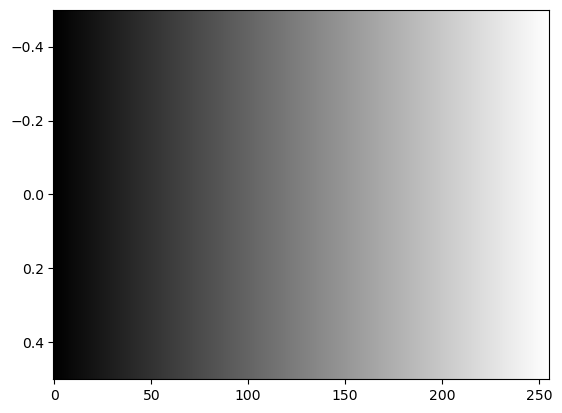

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
#Definicion de colores
colores=[(0,'black'),(1,'white')] # para generar escala de grices
cmap=LinearSegmentedColormap.from_list('degradado',colores)#listar los colores y generara color map a traves del array
imagen_degradado=cmap(np.linspace(0,1,256))
plt.imshow([imagen_degradado],aspect='auto')
plt.show()





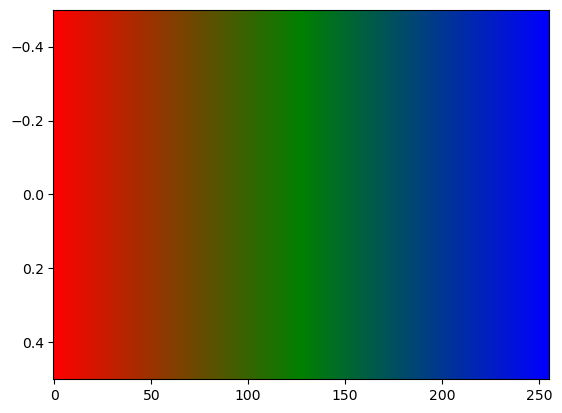

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
#Definicion de colores
colores=[(0,'red'),(0.5,'green'),(1,'blue')] # para generar escala de grices
cmap=LinearSegmentedColormap.from_list('degradado',colores)#listar los colores y generara color map a traves del array
imagen_degradado=cmap(np.linspace(0,1,256))
plt.imshow([imagen_degradado],aspect='auto')
plt.show()





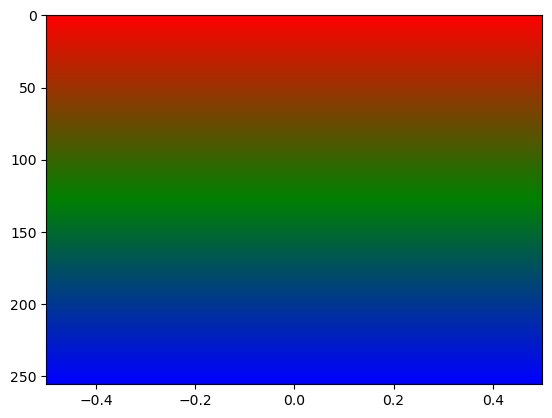

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
#Definicion de colores
colores=[(0,'red'),(0.5,'green'),(1,'blue')] # para generar escala de grices
cmap=LinearSegmentedColormap.from_list('degradado',colores)#listar los colores y generara color map a traves del array
imagen_degradado=cmap(np.linspace(0,1,256).reshape(-1,1))
plt.imshow(imagen_degradado,aspect='auto')
plt.show()





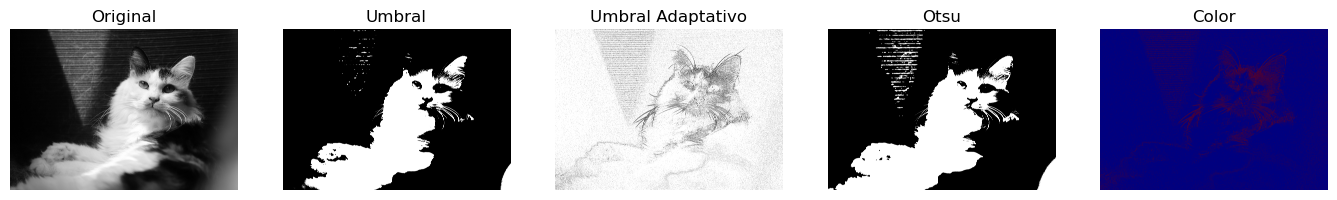

In [8]:
import cv2
import matplotlib.pyplot as plt
imagen=cv2.imread('imagenes/original/gato.jpeg',0)
_, umbral = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
umbral_adap=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
_, otsu = cv2.threshold(imagen, 125, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
color=cv2.applyColorMap(umbral_adap,cv2.COLORMAP_JET)
plt.figure(figsize=(17,9))
plt.subplot(1, 5, 1)
plt.title("Original")
plt.axis('off')
plt.imshow(imagen,cmap='gray')

plt.subplot(1, 5, 2)
plt.title("Umbral")
plt.axis('off')
plt.imshow(umbral,cmap='gray')

plt.subplot(1, 5, 3)
plt.title("Umbral Adaptativo")
plt.axis('off')
plt.imshow(umbral_adap,cmap='gray')

plt.subplot(1, 5, 4)
plt.title("Otsu")
plt.axis('off')
plt.imshow(otsu,cmap='gray')

plt.subplot(1, 5, 5)
plt.title("Color")
plt.axis('off')
plt.imshow(color,cmap='gray')

plt.show()

mascaras

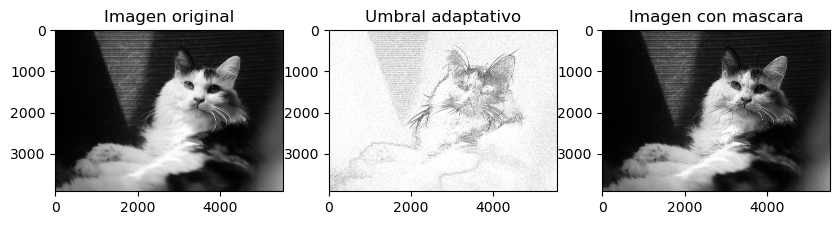

In [18]:
import cv2
import matplotlib.pyplot as plt
imagen=cv2.imread('imagenes/original/gato.jpeg',0)
umbral_adap=cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11,2)
mask=umbral_adap==255
img_junta=cv2.bitwise_and(imagen,imagen,mask=umbral_adap)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.title("Imagen original")
plt.imshow(imagen, cmap="gray")
plt.subplot(1, 3, 2)
plt.title("Umbral adaptativo")
plt.imshow(umbral_adap, cmap="gray")
plt.subplot(1, 3, 3)
plt.title("Imagen con mascara")
plt.imshow(img_junta, cmap="gray")
plt.show()

(np.float64(-0.5), np.float64(5534.5), np.float64(3910.5), np.float64(-0.5))

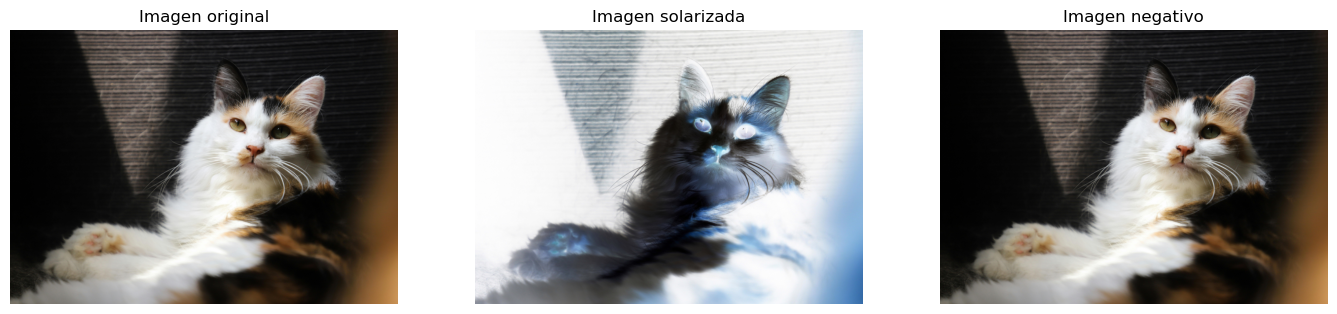

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('imagenes/original/gato.jpeg')
def solarizar(imagen,umbral):
    img_solarizada = np.where(imagen < umbral,imagen, 255 -  imagen)
    return img_solarizada
imagen_solarizada=solarizar(imagen,0)
imagen_negativo=255-imagen_solarizada
plt.figure(figsize=(17,9))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(imagen_solarizada,cv2.COLOR_BGR2RGB))
plt.title('Imagen solarizada')
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(imagen_negativo,cv2.COLOR_BGR2RGB))
plt.title('Imagen negativo')
plt.axis("off")





In [1]:
import cv2
import numpy as np

# Parámetros del tablero de ajedrez
dim_casilla = 100  # Tamaño de cada casilla (100x100 píxeles)
filas = 8  # Número de filas
columnas = 8  # Número de columnas

# Crear una imagen en blanco (tablero de ajedrez)
tablero = np.zeros((dim_casilla * filas, dim_casilla * columnas, 3), dtype=np.uint8)

# Llenar el tablero con los colores negro y blanco
for fila in range(filas):
    for columna in range(columnas):
        # Determinar el color de la casilla (blanca o negra)
        color = (255, 255, 255) if (fila + columna) % 2 == 0 else (0, 0, 0)
        # Dibujar la casilla
        cv2.rectangle(tablero, (columna * dim_casilla, fila * dim_casilla),
                      ((columna + 1) * dim_casilla, (fila + 1) * dim_casilla), color, -1)

# Guardar la imagen
cv2.imwrite('tablero_ajedrez.jpg', tablero)

# Mostrar la imagen
cv2.imshow('Tablero de Ajedrez', tablero)
cv2.waitKey(0)
cv2.destroyAllWindows()
